In [13]:
import os
os.chdir("C:/Users/Simon/Documents/UZH/DataAnalysiswithPython/SimonteBiesebeekPlayground/SimonteBiesebeekPlayground/FinalProject")
print(os.getcwd())

C:\Users\Simon\Documents\UZH\DataAnalysiswithPython\SimonteBiesebeekPlayground\SimonteBiesebeekPlayground\FinalProject


In [14]:
import os
import pandas as pd

csv_files = [f for f in os.listdir("Data") if f.endswith(".csv")]
dataframes = {f: pd.read_csv(os.path.join("Data", f)) for f in csv_files}



In [15]:
import os
path = r"C:\Users\Simon\Documents\UZH\DataAnalysiswithPython\SimonteBiesebeekPlayground\SimonteBiesebeekPlayground\FinalProject\Data"
print(os.path.exists(path))


True


In [16]:
files = os.listdir("Data")
print(files)

['Data2021.csv', 'Data2122.csv', 'Data2223.csv', 'Data2324.csv', 'Data2425.csv']


In [17]:
#data inspection
from pathlib import Path

data_folder = Path("Data")

# Create one combined DataFrame, adding a Season column automatically
seasonal_data = pd.concat(
    [
        pd.read_csv(f).assign(
            Season=f.stem.replace("Data", "")  # e.g. "Data2122" → "2122"
        )
        for f in data_folder.glob("*.csv")
    ],
    ignore_index=True
)
seasonal_data.to_csv("MergedDutchLeagueData.csv", index=False)
merged = pd.read_csv("MergedDutchLeagueData.csv")
merged.head()


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,N1,12/09/2020,17:45,Heerenveen,Willem II,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N1,12/09/2020,19:00,Zwolle,Feyenoord,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N1,12/09/2020,20:00,Twente,For Sittard,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N1,13/09/2020,11:15,FC Emmen,VVV Venlo,3,5,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N1,13/09/2020,13:30,Heracles,Den Haag,2,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print(merged.shape)

(1530, 132)


In [19]:
print(merged.columns)

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       '1XBCH', '1XBCD', '1XBCA', 'BFECH', 'BFECD', 'BFECA', 'BFEC>2.5',
       'BFEC<2.5', 'BFECAHH', 'BFECAHA'],
      dtype='object', length=132)


In [20]:
merged

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,N1,12/09/2020,17:45,Heerenveen,Willem II,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N1,12/09/2020,19:00,Zwolle,Feyenoord,0,2,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N1,12/09/2020,20:00,Twente,For Sittard,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N1,13/09/2020,11:15,FC Emmen,VVV Venlo,3,5,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N1,13/09/2020,13:30,Heracles,Den Haag,2,0,H,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525,N1,18/05/2025,13:30,Heracles,Nijmegen,1,2,A,0,0,...,2.38,3.57,3.02,2.36,3.7,3.15,1.75,2.26,2.04,1.92
1526,N1,18/05/2025,13:30,NAC Breda,Willem II,1,1,D,1,1,...,1.75,3.91,4.89,1.80,3.9,5.00,1.74,2.30,2.01,1.95
1527,N1,18/05/2025,13:30,Sparta Rotterdam,PSV Eindhoven,1,3,A,0,1,...,9.74,6.17,1.30,10.00,7.0,1.31,1.28,4.40,1.95,2.02
1528,N1,18/05/2025,13:30,Waalwijk,Go Ahead Eagles,5,3,H,1,1,...,2.61,4.14,2.46,2.62,4.1,2.64,1.42,3.30,1.98,2.00


In [21]:
seasonal_data['Winner'] = seasonal_data.apply(
    lambda row: row['HomeTeam'] if row['FTR'] == 'H' 
                else (row['AwayTeam'] if row['FTR'] == 'A' else 'Draw'),
    axis=1
)
print(seasonal_data.head())

  Div        Date   Time    HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  HTAG  \
0  N1  12/09/2020  17:45  Heerenveen    Willem II     2     0   H     1     0   
1  N1  12/09/2020  19:00      Zwolle    Feyenoord     0     2   A     0     1   
2  N1  12/09/2020  20:00      Twente  For Sittard     2     0   H     1     0   
3  N1  13/09/2020  11:15    FC Emmen    VVV Venlo     3     5   A     1     0   
4  N1  13/09/2020  13:30    Heracles     Den Haag     2     0   H     0     0   

   ... 1XBCD  1XBCA  BFECH  BFECD  BFECA  BFEC>2.5  BFEC<2.5  BFECAHH  \
0  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
1  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
2  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
3  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   
4  ...   NaN    NaN    NaN    NaN    NaN       NaN       NaN      NaN   

   BFECAHA      Winner  
0      NaN  Heerenveen  
1      NaN   Feyenoord  

In [22]:
seasonal_data['HomeTeam'].unique()

array(['Heerenveen', 'Zwolle', 'Twente', 'FC Emmen', 'Heracles',
       'Sparta Rotterdam', 'Groningen', 'Waalwijk', 'VVV Venlo',
       'AZ Alkmaar', 'Vitesse', 'PSV Eindhoven', 'For Sittard',
       'Den Haag', 'Feyenoord', 'Willem II', 'Ajax', 'Utrecht',
       'Go Ahead Eagles', 'Cambuur', 'Nijmegen', 'Excelsior', 'Volendam',
       'Almere City', 'NAC Breda'], dtype=object)

In [23]:
seasonal_data.isna().sum()

Div            0
Date           0
Time           0
HomeTeam       0
AwayTeam       0
            ... 
BFEC>2.5    1224
BFEC<2.5    1224
BFECAHH     1225
BFECAHA     1225
Winner         0
Length: 133, dtype: int64

In [24]:
seasonal_data.duplicated().sum()

np.int64(0)

In [25]:
print(seasonal_data.dtypes)

Div          object
Date         object
Time         object
HomeTeam     object
AwayTeam     object
             ...   
BFEC>2.5    float64
BFEC<2.5    float64
BFECAHH     float64
BFECAHA     float64
Winner       object
Length: 133, dtype: object


In [26]:
seasonal_data["GoalDifference"] = seasonal_data["FTHG"] - seasonal_data["FTAG"]
print(seasonal_data["GoalDifference"])

0       2
1      -2
2       2
3      -2
4       2
       ..
1525   -1
1526    0
1527   -2
1528    2
1529    2
Name: GoalDifference, Length: 1530, dtype: int64


In [27]:
print(seasonal_data["GoalDifference"].dtype)

int64


In [28]:
import numpy as np

# Assign points based on match result (FTR = 'H', 'A', 'D')
seasonal_data["HomePoints"] = np.select(
    [
        seasonal_data["FTR"] == "H",  # Home win
        seasonal_data["FTR"] == "D",  # Draw
        seasonal_data["FTR"] == "A"   # Away win
    ],
    [3, 1, 0]
)

seasonal_data["AwayPoints"] = np.select(
    [
        seasonal_data["FTR"] == "A",  # Away win
        seasonal_data["FTR"] == "D",  # Draw
        seasonal_data["FTR"] == "H"   # Home win
    ],
    [3, 1, 0]
)

print(seasonal_data[["FTR", "HomePoints", "AwayPoints"]])


     FTR  HomePoints  AwayPoints
0      H           3           0
1      A           0           3
2      H           3           0
3      A           0           3
4      H           3           0
...   ..         ...         ...
1525   A           0           3
1526   D           1           1
1527   A           0           3
1528   H           3           0
1529   H           3           0

[1530 rows x 3 columns]


In [46]:
home_points = seasonal_data.groupby("HomeTeam")["HomePoints"].sum().reset_index()
away_points = seasonal_data.groupby("AwayTeam")["AwayPoints"].sum().reset_index()
total_points = pd.merge(home_points, away_points, left_on="HomeTeam", right_on="AwayTeam", how="outer").fillna(0)
total_points["Team"] = total_points["HomeTeam"].combine_first(total_points["AwayTeam"])
print(total_points.head())

      HomeTeam  HomePoints     AwayTeam  AwayPoints         Team
0   AZ Alkmaar         170   AZ Alkmaar         151   AZ Alkmaar
1         Ajax         197         Ajax         177         Ajax
2  Almere City          27  Almere City          29  Almere City
3      Cambuur          27      Cambuur          31      Cambuur
4     Den Haag           9     Den Haag          13     Den Haag


In [39]:
home_gd = seasonal_data.groupby("HomeTeam")["GoalDifference"].sum().reset_index()
away_gd = seasonal_data.groupby("AwayTeam")["GoalDifference"].sum().reset_index()
total_gd = pd.merge(home_gd, away_gd, left_on="HomeTeam", right_on="AwayTeam", how="outer")
total_gd["Team"] = total_gd["HomeTeam"].combine_first(total_gd["AwayTeam"])
print(total_gd)

            HomeTeam  GoalDifference_x          AwayTeam  GoalDifference_y  \
0         AZ Alkmaar                89        AZ Alkmaar               -50   
1               Ajax               168              Ajax               -86   
2        Almere City               -35       Almere City                32   
3            Cambuur               -25           Cambuur                35   
4           Den Haag               -21          Den Haag                26   
5          Excelsior                -5         Excelsior                57   
6           FC Emmen               -22          FC Emmen                38   
7          Feyenoord               132         Feyenoord               -93   
8        For Sittard               -24       For Sittard                74   
9    Go Ahead Eagles                24   Go Ahead Eagles                45   
10         Groningen                 0         Groningen                68   
11        Heerenveen                 5        Heerenveen        

In [50]:
print(total_points.columns)
print(total_gd.columns)


Index(['HomeTeam', 'HomePoints', 'AwayTeam', 'AwayPoints', 'Team'], dtype='object')
Index(['HomeTeam', 'GoalDifference_x', 'AwayTeam', 'GoalDifference_y', 'Team'], dtype='object')


In [51]:
print(league_table.columns)

Index(['HomeTeam_x', 'HomePoints', 'AwayTeam_x', 'AwayPoints', 'Team',
       'HomeTeam_y', 'GoalDifference_x', 'AwayTeam_y', 'GoalDifference_y'],
      dtype='object')


In [49]:
league_table = pd.merge(total_points, total_gd, on="Team", how="left")
print(league_table.sort_values("total_points", ascending=False))

KeyError: 'total_points'

In [ ]:
total_points["HomePointsPct"] = (total_points["HomePoints"] / total_points["TotalPoints"]) * 100
print(total_points.dtypes)


HomeTeam          object
HomePoints         int64
AwayTeam          object
AwayPoints         int64
Team              object
TotalPoints        int64
HomePointsPct    float64
dtype: object


In [ ]:
total_points["Team"] = total_points["HomeTeam"].combine_first(total_points["AwayTeam"])
total_points["TotalPoints"] = total_points["HomePoints"].fillna(0) + total_points["AwayPoints"].fillna(0)
total_points["HomePointsPct"] = (total_points["HomePoints"] / total_points["TotalPoints"]) * 100
print(total_points)


            HomeTeam  HomePoints          AwayTeam  AwayPoints  \
0         AZ Alkmaar         170        AZ Alkmaar         151   
1               Ajax         197              Ajax         177   
2        Almere City          27       Almere City          29   
3            Cambuur          27           Cambuur          31   
4           Den Haag           9          Den Haag          13   
5          Excelsior          45         Excelsior          16   
6           FC Emmen          34          FC Emmen          24   
7          Feyenoord         187         Feyenoord         177   
8        For Sittard         109       For Sittard          82   
9    Go Ahead Eagles         108   Go Ahead Eagles          65   
10         Groningen          87         Groningen          56   
11        Heerenveen         122        Heerenveen          84   
12          Heracles         101          Heracles          48   
13         NAC Breda          24         NAC Breda           9   
14        

In [ ]:
total_points = total_points[["Team", "HomePoints", "AwayPoints", "TotalPoints", "HomePointsPct"]]
print(total_points.sort_values("HomePointsPct", ascending=False))

                Team  HomePoints  AwayPoints  TotalPoints  HomePointsPct
5          Excelsior          45          16           61      73.770492
13         NAC Breda          24           9           33      72.727273
21          Volendam          39          16           55      70.909091
12          Heracles         101          48          149      67.785235
22          Waalwijk         106          57          163      65.030675
9    Go Ahead Eagles         108          65          173      62.427746
23         Willem II          56          34           90      62.222222
10         Groningen          87          56          143      60.839161
11        Heerenveen         122          84          206      59.223301
6           FC Emmen          34          24           58      58.620690
17            Twente         173         123          296      58.445946
8        For Sittard         109          82          191      57.068063
24            Zwolle          81          61       

In [ ]:
import statsmodels.api as sm

# Home team regression: HS vs FTHG
X_home = seasonal_data['HS']           # independent variable
y_home = seasonal_data['FTHG']         # dependent variable

X_home = sm.add_constant(X_home)  # add intercept
model_home = sm.OLS(y_home, X_home).fit()

print(model_home.summary())

                            OLS Regression Results                            
Dep. Variable:                   FTHG   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     252.0
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           1.20e-52
Time:                        17:29:06   Log-Likelihood:                -2596.4
No. Observations:                1530   AIC:                             5197.
Df Residuals:                    1528   BIC:                             5208.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4182      0.086      4.862      0.0

In [ ]:
seasonal_data['Shots_Difference'] = seasonal_data['HS'] - seasonal_data['AS']
print(seasonal_data['Shots_Difference'])

0        3
1        4
2       12
3        1
4       14
        ..
1525     8
1526     6
1527   -20
1528    -9
1529     0
Name: Shots_Difference, Length: 1530, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)
X = seasonal_data[['Shots_Difference']]  # predictor
y = seasonal_data['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for Shots_Difference: {model.coef_[0][0]}")

# Predict probabilities
seasonal_data['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.5237942857853533
Coefficient for Shots_Difference: 0.08176126733800303


In [ ]:
seasonal_data['ShotsonTarget_Difference'] = seasonal_data['HST'] - seasonal_data['AST']
print(seasonal_data['ShotsonTarget_Difference'])

0       2
1      -1
2       5
3      -2
4       4
       ..
1525    0
1526    0
1527   -9
1528    2
1529    1
Name: ShotsonTarget_Difference, Length: 1530, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)
X = seasonal_data[['ShotsonTarget_Difference']]  # predictor
y = seasonal_data['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for ShotsonTarget_Difference: {model.coef_[0][0]}")

# Predict probabilities
seasonal_data['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.7378306632954255
Coefficient for ShotsonTarget_Difference: 0.3704470512301706


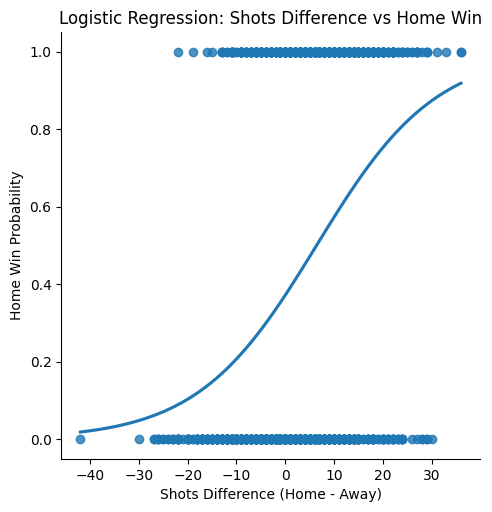

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Home win = 1, else = 0
seasonal_data['HomeWin'] = (seasonal_data['Winner'] == seasonal_data['HomeTeam']).astype(int)

sns.lmplot(x='Shots_Difference', y='HomeWin', data=seasonal_data, logistic=True, ci=None)
plt.xlabel('Shots Difference (Home - Away)')
plt.ylabel('Home Win Probability')
plt.title('Logistic Regression: Shots Difference vs Home Win')
plt.show()

In [ ]:
seasonal_data.groupby('Season')['HomeTeam'].nunique()

Season
2021    18
2122    18
2223    18
2324    18
2425    18
Name: HomeTeam, dtype: int64

In [ ]:
seasonal_data['Season'].value_counts()

Season
2021    306
2122    306
2223    306
2324    306
2425    306
Name: count, dtype: int64

In [ ]:
seasonal_data['FTR'].value_counts()

FTR
H    666
A    496
D    368
Name: count, dtype: int64

In [ ]:
#from the above statistics, it is evident that home teams win more frequently than away teams or draws.

In [ ]:
seasonal_data[['FTHG', 'FTAG']].mean()

FTHG    1.673856
FTAG    1.356209
dtype: float64

In [ ]:
goals = (
    seasonal_data.groupby('HomeTeam')['FTHG'].sum()
    + seasonal_data.groupby('AwayTeam')['FTAG'].sum()
)
print(goals.sort_values(ascending=False))

HomeTeam
PSV Eindhoven       463
Ajax                427
Feyenoord           389
AZ Alkmaar          335
Twente              300
Utrecht             269
Sparta Rotterdam    229
Heerenveen          219
Waalwijk            205
Nijmegen            199
For Sittard         199
Go Ahead Eagles     187
Vitesse             169
Heracles            158
Zwolle              158
Groningen           152
Willem II           106
Excelsior            82
Cambuur              79
Volendam             76
FC Emmen             73
Almere City          56
VVV Venlo            43
NAC Breda            34
Den Haag             29
dtype: int64


<Axes: xlabel='Season'>

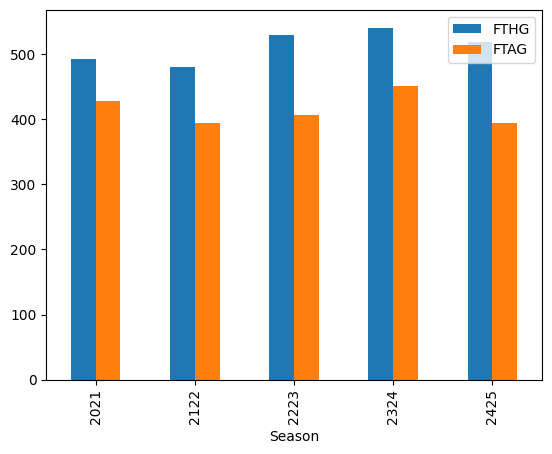

In [35]:
seasonal_data.groupby('Season')[['FTHG', 'FTAG']].sum().plot(kind='bar')

<Axes: xlabel='Season'>

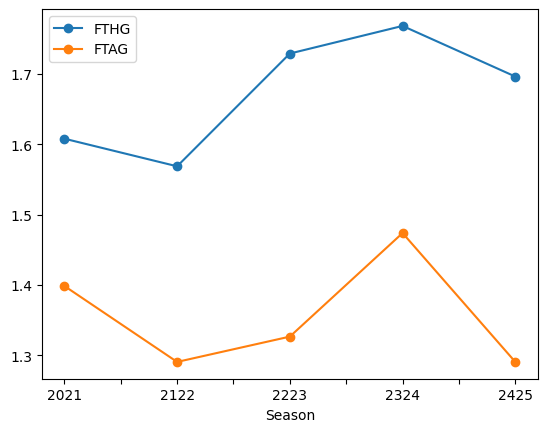

In [36]:
seasonal_data.groupby('Season')[['FTHG', 'FTAG']].mean().plot(marker='o')

<Axes: title={'center': 'Average Home Points Percentage per Season'}, xlabel='Season'>

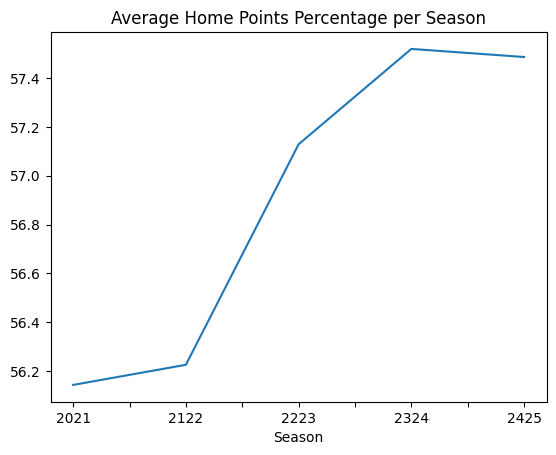

In [66]:
seasonal_data['HomePointsPct'] = (seasonal_data['HomePoints'] / (seasonal_data['HomePoints'] + seasonal_data['AwayPoints'])) * 100
home_points = seasonal_data.groupby('Season')['HomePointsPct'].mean()
home_points.plot(title='Average Home Points Percentage per Season')

In [67]:
seasonal_data.corr(numeric_only=True)

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,BFECAHH,BFECAHA,GoalDifference,HomePoints_x,AwayPoints_x,HomePoints_y,AwayPoints_y,HomePoints,AwayPoints,HomePointsPct
FTHG,1.000000,-0.178388,0.718585,-0.082551,0.376266,-0.242786,0.629282,-0.225394,-0.127455,-0.111078,...,-0.172111,-0.047866,0.791854,0.667085,-0.613205,0.343206,0.335810,0.343206,0.335810,-0.084002
FTAG,-0.178388,1.000000,-0.123500,0.687914,-0.230628,0.453657,-0.249691,0.658892,-0.005268,-0.049901,...,-0.034536,0.125002,-0.742172,-0.624607,0.670312,-0.246757,-0.237980,-0.246757,-0.237980,0.050431
HTHG,0.718585,-0.123500,1.000000,-0.106275,0.184571,-0.136964,0.413420,-0.147843,-0.086376,-0.077558,...,-0.198548,-0.145639,0.566106,0.480604,-0.432998,0.283257,0.266894,0.283257,0.266894,-0.048321
HTAG,-0.082551,0.687914,-0.106275,1.000000,-0.102774,0.233094,-0.142836,0.390127,0.004430,-0.001413,...,-0.048110,0.114511,-0.483193,-0.407233,0.433922,-0.137180,-0.140223,-0.137180,-0.140223,0.018593
HS,0.376266,-0.230628,0.184571,-0.102774,1.000000,-0.476661,0.720526,-0.349558,-0.200018,-0.019224,...,-0.144876,-0.142058,0.399430,0.320045,-0.334297,0.374438,0.379897,0.374438,0.379897,-0.127469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HomePoints_y,0.343206,-0.246757,0.283257,-0.137180,0.374438,-0.373557,0.376429,-0.310744,-0.127527,-0.027483,...,-0.067062,-0.120332,0.386923,0.343538,-0.331589,1.000000,0.947491,1.000000,0.947491,-0.238499
AwayPoints_y,0.335810,-0.237980,0.266894,-0.140223,0.379897,-0.382299,0.376209,-0.312783,-0.117287,-0.001046,...,-0.055201,-0.116940,0.376438,0.323609,-0.315538,0.947491,1.000000,0.947491,1.000000,-0.485457
HomePoints,0.343206,-0.246757,0.283257,-0.137180,0.374438,-0.373557,0.376429,-0.310744,-0.127527,-0.027483,...,-0.067062,-0.120332,0.386923,0.343538,-0.331589,1.000000,0.947491,1.000000,0.947491,-0.238499
AwayPoints,0.335810,-0.237980,0.266894,-0.140223,0.379897,-0.382299,0.376209,-0.312783,-0.117287,-0.001046,...,-0.055201,-0.116940,0.376438,0.323609,-0.315538,0.947491,1.000000,0.947491,1.000000,-0.485457


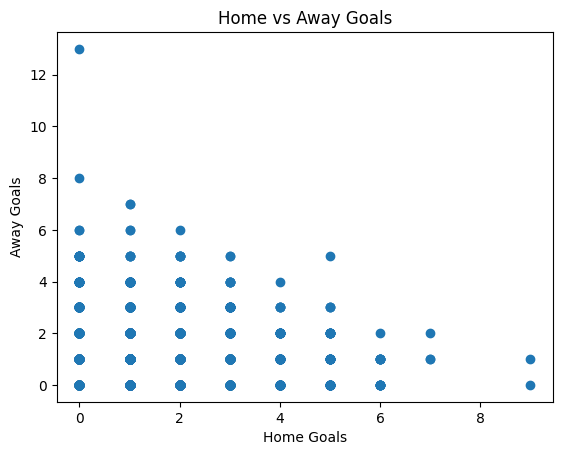

In [68]:
import matplotlib.pyplot as plt
plt.scatter(seasonal_data['FTHG'], seasonal_data['FTAG'])
plt.xlabel('Home Goals')
plt.ylabel('Away Goals')
plt.title('Home vs Away Goals')
plt.show()

In [70]:
avg_goals = seasonal_data.groupby('HomeTeam')['FTHG'].mean().sort_values(ascending=False)
print(avg_goals)


HomeTeam
PSV Eindhoven       2.952941
Ajax                2.811765
Feyenoord           2.352941
AZ Alkmaar          2.141176
Twente              2.035294
Go Ahead Eagles     1.705882
Nijmegen            1.647059
Utrecht             1.600000
Heracles            1.544118
Heerenveen          1.482353
Sparta Rotterdam    1.447059
Excelsior           1.411765
Waalwijk            1.376471
Volendam            1.323529
For Sittard         1.317647
Cambuur             1.264706
Vitesse             1.250000
FC Emmen            1.235294
NAC Breda           1.235294
Groningen           1.205882
VVV Venlo           1.176471
Willem II           1.176471
Zwolle              1.102941
Den Haag            1.000000
Almere City         0.911765
Name: FTHG, dtype: float64


In [72]:
defense = seasonal_data.groupby('AwayTeam')['FTHG'].mean().sort_values()
print(defense)

AwayTeam
Almere City         0.911765
Den Haag            1.000000
Zwolle              1.102941
VVV Venlo           1.176471
Willem II           1.176471
Groningen           1.205882
NAC Breda           1.235294
FC Emmen            1.235294
Vitesse             1.250000
Cambuur             1.264706
For Sittard         1.317647
Volendam            1.323529
Waalwijk            1.376471
Excelsior           1.411765
Sparta Rotterdam    1.447059
Heerenveen          1.482353
Heracles            1.544118
Utrecht             1.600000
Nijmegen            1.647059
Go Ahead Eagles     1.705882
Twente              2.035294
AZ Alkmaar          2.141176
Feyenoord           2.352941
Ajax                2.811765
PSV Eindhoven       2.952941
Name: FTHG, dtype: float64


In [74]:
team_stats = pd.DataFrame({
    'AvgGoalsScored': seasonal_data.groupby('HomeTeam')['FTHG'].mean(),
    'AvgGoalsConceded': seasonal_data.groupby('HomeTeam')['FTAG'].mean(),
})
print(team_stats)

                  AvgGoalsScored  AvgGoalsConceded
HomeTeam                                          
AZ Alkmaar              2.141176          1.094118
Ajax                    2.811765          0.835294
Almere City             0.911765          1.941176
Cambuur                 1.264706          2.000000
Den Haag                1.000000          2.235294
Excelsior               1.411765          1.558824
FC Emmen                1.235294          1.882353
Feyenoord               2.352941          0.800000
For Sittard             1.317647          1.600000
Go Ahead Eagles         1.705882          1.352941
Groningen               1.205882          1.205882
Heerenveen              1.482353          1.423529
Heracles                1.544118          1.455882
NAC Breda               1.235294          1.294118
Nijmegen                1.647059          1.455882
PSV Eindhoven           2.952941          0.882353
Sparta Rotterdam        1.447059          1.352941
Twente                  2.03529

<Axes: >

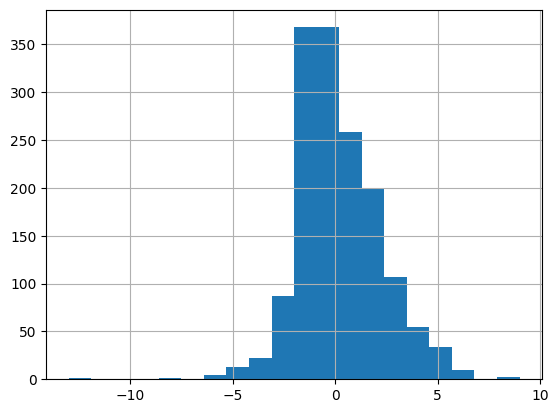

In [ ]:
seasonal_data['GoalDiff'] = seasonal_data['FTHG'] - seasonal_data['FTAG']
seasonal_data['GoalDiff'].hist(bins=20)
#from this graph, it is interesting to see that if the away team wins, they win way more often by 1 goal than by 2 or more goals, whereas for the home team, it is a bit more spread. 

In [77]:
seasonal_data['TotalGoals'] = seasonal_data['FTHG'] + seasonal_data['FTAG']
print(seasonal_data.loc[seasonal_data['TotalGoals'].idxmax()])

Div                      N1
Date             24/10/2020
Time                  15:30
HomeTeam          VVV Venlo
AwayTeam_x             Ajax
                    ...    
AwayPoints               10
Team_y            VVV Venlo
HomePointsPct     56.521739
GoalDiff                -13
TotalGoals               13
Name: 44, Length: 147, dtype: object
